In [19]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Load forking paths result for math_open prompt #4
with open("data/forking_paths/deepseek_llama_8b/math_open/06.json") as f:
    branches = json.load(f)

# Load the base dataset entry
with open("data/collection/deepseek_llama_8b/math_open.json") as f:
    base_data = json.load(f)

datapoint = base_data[6]
correct_answer = "76.80"  # boxed answer from correct_answer field

print(f"Question: {datapoint['question']}")
print(f"Correct answer: {correct_answer}")
print(f"Base model answer: {datapoint['clean_answer']}")
print(f"Total branches: {len(branches)}")
print(f"Unique t values: {len(set(b['t'] for b in branches))}")

Question: Suppose $r$ is a real number for which
\[\left\lfloor r + \frac{19}{100} \right\rfloor + \left\lfloor r + \frac{20}{100} \right\rfloor + \left\lfloor r + \frac{21}{100} \right\rfloor + \cdots + \left\lfloor r + \frac{91}{100} \right\rfloor = 546.\]Find $\lfloor 100r \rfloor.$
Correct answer: 76.80
Base model answer: 743
Total branches: 8100
Unique t values: 270


In [20]:
def normalize_answer(ans: str) -> str:
    """Strip leading $ and trailing . so '$76.' and '76.' map to the same bucket."""
    return ans.strip().lstrip("$").rstrip(".")

# Build a DataFrame with one row per branch
df = pd.DataFrame(branches)
df["outcome"] = df["clean_answer"].apply(normalize_answer)

# Compute outcome probability at each t
def compute_outcome_probs(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for t, group in df.groupby("t"):
        counts = Counter(group["outcome"])
        total = len(group)
        for outcome, count in counts.items():
            rows.append({"t": t, "outcome": outcome, "outcome_probability": count / total, "num_rollouts": count})
    return pd.DataFrame(rows)

prob_df = compute_outcome_probs(df)

# Keep only the top N outcomes overall for legibility
top_outcomes = df["outcome"].value_counts().head(5).index.tolist()
prob_df_top = prob_df[prob_df["outcome"].isin(top_outcomes)]

print("Top outcomes (normalized):")
print(df["outcome"].value_counts().head(10))

Top outcomes (normalized):
outcome
743     4800
none    2192
742      797
746       56
744       49
713       42
700       20
43        18
35        14
747       12
Name: count, dtype: int64


In [21]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("deepseek-ai/DeepSeek-R1-Distill-Llama-8B")
output_token_ids = datapoint["output_token_ids"]

# Find </think> token position
think_finish_idx = -1
for i, tok in enumerate(tokenizer.convert_ids_to_tokens(output_token_ids)):
    if "</think>" in tok:
        think_finish_idx = i
        break

print(f"Output length: {len(output_token_ids)} tokens")
print(f"</think> token index: {think_finish_idx}")

Output length: 4533 tokens
</think> token index: 3981


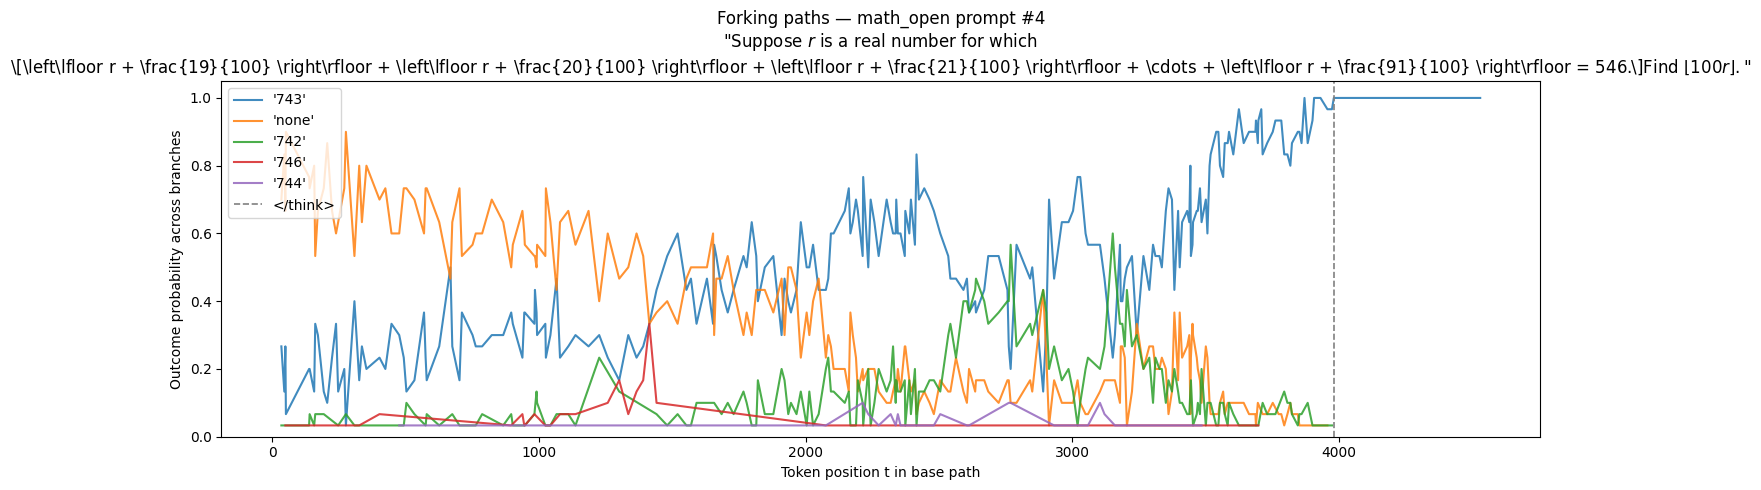

In [22]:
fig, ax = plt.subplots(figsize=(14, 5))

colors = plt.cm.tab10.colors
for i, outcome in enumerate(top_outcomes):
    sub = prob_df_top[prob_df_top["outcome"] == outcome].sort_values("t")
    label = f"{outcome!r} (correct)" if outcome == normalize_answer(correct_answer) else repr(outcome)
    ax.plot(sub["t"], sub["outcome_probability"], label=label, color=colors[i], alpha=0.85)

# Mark </think> position
if think_finish_idx >= 0:
    ax.axvline(think_finish_idx, color="gray", linestyle="--", linewidth=1.2, label="</think>")

ax.set_xlabel("Token position t in base path")
ax.set_ylabel("Outcome probability across branches")
ax.set_title(f"Forking paths — math_open prompt #4\n\"{datapoint['question']}\"")
ax.legend(loc="upper left")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

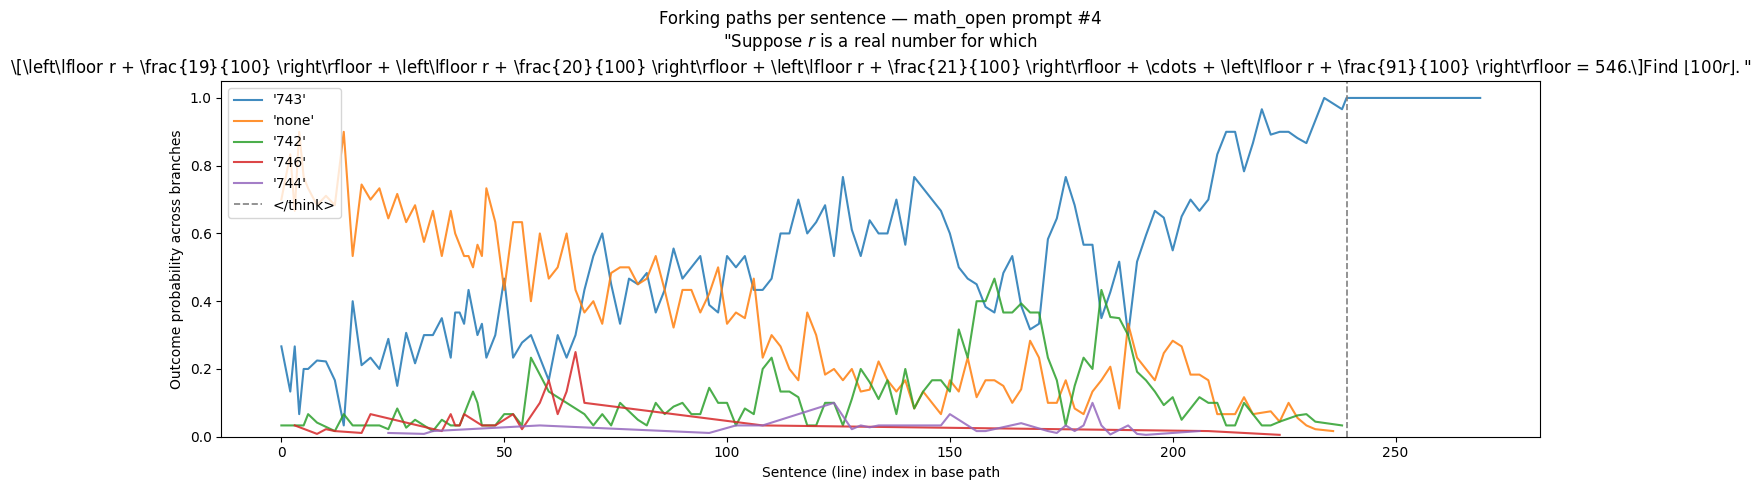

In [23]:
import bisect

# Split base path into sentences by newline (reasoning traces are newline-separated)
full_text = tokenizer.decode(output_token_ids)
raw_lines = full_text.split("\n")

# Cumulative char positions of each line end in full_text
line_end_chars = []
pos = 0
for line in raw_lines:
    pos += len(line) + 1  # +1 for the \n
    line_end_chars.append(pos)

# Map each unique t to a sentence (line) index
unique_ts = sorted(df["t"].unique())
t_to_sent = {}
for t in unique_ts:
    prefix_len = len(tokenizer.decode(output_token_ids[:t]))
    t_to_sent[t] = bisect.bisect_right(line_end_chars, prefix_len)

df["sentence"] = df["t"].map(t_to_sent)

# Aggregate outcome probabilities per sentence (pool all branches within each sentence)
def compute_sentence_probs(df):
    rows = []
    for sent_idx, group in df.groupby("sentence"):
        counts = Counter(group["outcome"])
        total = len(group)
        for outcome, count in counts.items():
            rows.append({"sentence": sent_idx, "outcome": outcome, "outcome_probability": count / total})
    return pd.DataFrame(rows)

sent_prob_df = compute_sentence_probs(df)
sent_prob_df_top = sent_prob_df[sent_prob_df["outcome"].isin(top_outcomes)]

think_sent = t_to_sent.get(think_finish_idx, -1)

fig, ax = plt.subplots(figsize=(14, 5))
colors = plt.cm.tab10.colors
for i, outcome in enumerate(top_outcomes):
    sub = sent_prob_df_top[sent_prob_df_top["outcome"] == outcome].sort_values("sentence")
    label = f"{outcome!r} (correct)" if outcome == normalize_answer(correct_answer) else repr(outcome)
    ax.plot(sub["sentence"], sub["outcome_probability"], label=label, color=colors[i], alpha=0.85)

if think_sent >= 0:
    ax.axvline(think_sent, color="gray", linestyle="--", linewidth=1.2, label="</think>")

ax.set_xlabel("Sentence (line) index in base path")
ax.set_ylabel("Outcome probability across branches")
ax.set_title(f"Forking paths per sentence — math_open prompt #4\n\"{datapoint['question']}\"")
ax.legend(loc="upper left")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [24]:
base_path_text = tokenizer.decode(output_token_ids)
print(base_path_text)

Okay, so I have this problem here where I need to find the floor of 100r, given that the sum of a series of floor functions equals 546. Let me try to break it down step by step.

The problem says:
\[
\left\lfloor r + \frac{19}{100} \right\rfloor + \left\lfloor r + \frac{20}{100} \right\rfloor + \left\lfloor r + \frac{21}{100} \right\rfloor + \cdots + \left\lfloor r + \frac{91}{100} \right\rfloor = 546.
\]
And I need to find \(\lfloor 100r \rfloor\).

Hmm, okay. So, this is a sum of floor functions. Each term is the floor of r plus a fraction from 19/100 up to 91/100. Let me first figure out how many terms are in this sum.

Looking at the denominators, it starts at 19 and goes up to 91. So, 91 - 19 + 1 = 73 terms. So, 73 terms in total.

Wait, let me double-check: 91 minus 19 is 72, plus 1 is 73. Yep, 73 terms.

Now, each term inside the floor function is \( r + \frac{k}{100} \) where k starts at 19 and ends at 91.

I need to compute the sum of these floor functions and set it equal to 